In [4]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
FASTA_PATH = "/home/nboley/src/Ravel/data/repo_data_manifest/reference/GRCh38/GRCh38.p12.genome.fa.gz"

In [5]:
from data import HematopoieticGeneExpression
hge = HematopoieticGeneExpression.load()

In [10]:
import os
import pandas as pd
from fragmentomics_tools.dataframe import RegionDataFrame

def build_ctcf_binding_sites():
    ### load and merge all of the binding sites #######################################################################
    base_dir = "/scratch/ctcf_analysis/CTCF/cell_type_merged"
    index_cols = ['contig', 'start', 'stop', 'strand']
    dfs = []
    for fname in os.listdir(base_dir):
        # extract the biosample type from the filename
        cell_type = fname.split('.')[1]
        # load the data into a region dataframe
        df = pd.read_table(os.path.join(base_dir, fname))
        # subset the dataframe by the binding site locations
        df = df[['contig', 'start', 'stop', 'strand', 'tf_top_score']].set_index(index_cols)
        # rename the score column to the biosample_type
        df = df.rename(columns={'tf_top_score': cell_type})
        df = df.sort_values(df.columns[0], ascending=False).head(20000).sort_index()
        dfs.append(df)

    # merge everything
    df = dfs[0]
    for i in range(1, len(dfs)): 
        df = df.join(dfs[i], how='outer')
        
    # binarize based upon peak presence
    df = pd.DataFrame(df.fillna(0).sort_index())
    df = (df > 1e-6).astype(int)
    
    # neutrophils look weird
    df = df.drop(columns='neutrophil')

    return RegionDataFrame(df.reset_index(), ref='hg38')

In [11]:
ctcf_rdf = build_ctcf_binding_sites()

In [12]:
ctcf_rdf

,contig,start,stop,strand,"CD8-positive,_alpha-beta_T_cell",mucosa_of_descending_colon,B_cell,neural_cell,osteoblast,sigmoid_colon,natural_killer_cell,transverse_colon,stomach,dorsolateral_prefrontal_cortex,CD14-positive_monocyte,neural_crest_cell,neural_progenitor_cell
0,chr1,91419,91436,+,0,0,1,1,0,0,0,0,0,0,0,0,0
1,chr1,181743,181760,-,1,0,1,0,0,1,1,1,0,1,1,1,1
2,chr1,267998,268015,+,1,1,1,1,0,1,1,1,1,1,1,0,0
3,chr1,586152,586169,+,1,0,1,0,0,1,0,1,0,1,1,0,0
4,chr1,609382,609399,+,0,0,0,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48032,chrX,155651425,155651442,-,0,0,1,0,1,0,1,0,0,0,1,1,0
48033,chrX,155662512,155662529,+,0,0,1,0,0,0,0,1,0,0,0,0,0
48034,chrX,155820326,155820343,-,1,0,0,1,0,1,1,0,1,1,1,0,0
48035,chrX,155967078,155967095,+,1,0,1,0,1,0,0,0,0,1,0,1,1


In [13]:
import os
import pandas as pd
import numpy as np
from torchvision.io import read_image
from torch.utils.data import Dataset, DataLoader

class FragmentEndpointsDataset(Dataset):
    def __init__(self, srdf):
        self.srdf = srdf

    def __len__(self):
        return len(self.srdf)

    def __getitem__(self, idx):
        record = self.srdf.iloc[idx, :]
        inputs = torch.Tensor(record.one_hot_encoded_sequence.T)

        fwd_fa = record.fragment_array.subset_by_fragment_strand("+")
        bkwd_fa = record.fragment_array.subset_by_fragment_strand("-")
        targets = torch.cat(
            [
                torch.Tensor(fwd_fa.first_covered_base_counts.astype(float))[None, :].cuda(),
                torch.Tensor(bkwd_fa.first_covered_base_counts.astype(float))[None, :].cuda(),
                torch.Tensor(fwd_fa.last_covered_base_counts.astype(float))[None, :].cuda(),
                torch.Tensor(bkwd_fa.last_covered_base_counts.astype(float))[None, :].cuda(),
            ],
            dim=0,
        ).cuda()

        return inputs, targets



WARNING	2024-03-15 16:04:16,786	/home/nboley/miniconda3/envs/fragmentomics_tools_dev/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/nboley/miniconda3/envs/fragmentomics_tools_dev/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c104warnERKNS_7WarningE'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(



In [14]:
import os
import torch
from torch import optim, nn, utils, Tensor
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
import lightning as L

# define any number of nn.Modules (or use your current ones)
encoder = nn.Sequential(nn.Linear(28 * 28, 64), nn.ReLU(), nn.Linear(64, 3))
decoder = nn.Sequential(nn.Linear(3, 64), nn.ReLU(), nn.Linear(64, 28 * 28))


# define the LightningModule
class BackgroundModelModule(L.LightningModule):
    def _init_model(self, path):
        if path is not None:
            state_dict = torch.load(path)
            self.kernel_size = state_dict.pop("kernel_size")
            self.num_filters = state_dict.pop("num_filters")
        else:
            self.kernel_size = 16
            self.num_filters = 64

        self.verbose = True
        self.num_workers = 64

        self.model = torch.nn.Sequential(
            *[
                torch.nn.Conv1d(
                    in_channels=4,
                    out_channels=self.num_filters,
                    kernel_size=self.kernel_size,
                    padding="valid",
                ),
                torch.nn.Conv1d(
                    in_channels=self.num_filters,
                    out_channels=4,
                    kernel_size=self.kernel_size,
                    padding="valid",
                ),
            ]
        )
        if path is not None:
            self.model.load_state_dict(state_dict)
        self.model.cuda()


    def __init__(self, path=None):
        super().__init__()
        self._init_model(path)

    def training_step(self, batch, batch_idx):
        # training_step defines the train loop.
        # it is independent of forward
        x, y = batch
        y_hat = self.model(x)
        loss = nn.functional.mse_loss(y_hat, y[:, :, 15:-15])
        # Logging to TensorBoard (if installed) by default
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=1e-3)
        return optimizer


# init the autoencoder
background_model = BackgroundModelModule()

# Old Method

In [37]:
import itertools
from typing import Optional # , Dict, Type, Union, Tuple, List

import numpy
import pandas
import torch
import torch.optim as optim
from torch.nn.modules.loss import _Loss

import matplotlib.pyplot as plt

from fragmentomics_tools.dataframe import DataFrameBase
from fragmentomics_tools.region import Region

# from ravel.learn.functional_genomics.losses import MultinomialNLLLoss

from scipy.stats import multinomial
from scipy.special import softmax

def calculate_start_and_stop_from_jitter(
    input_length, output_length, jitter_value, strand: Optional[str] = None
):
    """
    Calculates the new start and stop of a region given some +/- jitter value and output length
    Importantly, this is only defined on input / output lengths of the same parity:
        allowed: (even, even), (odd, odd)
        disallowed: (even, odd), (odd, even)
    :param input_length: length of input region
    :param output_length: desired output length of region
    :param jitter_value: a +/- value from the center of the input region by which to shift window
    :param strand: Optional strand, if not supplied this will default to assuming the user wants + strand.
    :return: coordinates for, e.g., slicing
    """
    if input_length < output_length + numpy.abs(jitter_value):
        raise ValueError(
            f"input array is not wide enough to allow for an output of"
            f" length {output_length} with jitter_value of {jitter_value}."
        )

    resize_start = Region.get_resize_start(
        start=0, current_size=input_length, new_size=output_length, strand=strand
    )
    jitter_start = resize_start + jitter_value
    jitter_stop = jitter_start + output_length
    return jitter_start, jitter_stop


def jitter_matrix(input_arr, jitter_value, output_length, strand: Optional[str] = None):
    input_length = input_arr.shape[-1]

    if round(jitter_value) != jitter_value:
        raise ValueError(f"jitter_range must be a whole number, received {jitter_value}.")

    if input_length < output_length + numpy.abs(jitter_value):
        raise ValueError(
            f"input array is not wide enough to allow for an output of"
            f" length {output_length} with jitter_value of {jitter_value}."
        )

    new_start, new_stop = calculate_start_and_stop_from_jitter(
        input_length=input_length, output_length=output_length, jitter_value=jitter_value, strand=strand
    )
    assert new_stop - new_start == output_length, (output_length, new_stop, new_start)
    assert new_start >= 0, new_start
    assert new_stop <= input_length, (new_stop, input_length)

    if isinstance(input_arr, numpy.ndarray) or isinstance(input_arr, torch.Tensor):
        jittered_output = input_arr[..., new_start:new_stop]
    elif scipy.sparse.issparse(input_arr):
        indices = numpy.where((input_arr.col < new_stop) & (input_arr.col >= new_start))[0]

        jittered_output = coo_matrix(
            (
                numpy.ones(len(indices)),
                (input_arr.row[indices], input_arr.col[indices] - new_start),
            ),
            shape=[input_arr.shape[0], output_length],
            dtype=input_arr.dtype,
        )
    else:
        raise TypeError(f"input_arr type {type(input_arr)} is invalid.")

    return jittered_output



class MultinomialNLLLoss(_Loss):
    def __init__(
        self,
        size_average=None,
        reduce=None,
        is_probs=False,
        reduction: str = "mean",
        scale_loss_to_d: bool = False,
    ) -> None:
        """Multinomial Negative Log Likelihood Loss

        :param size_average: (bool, optional) Deprecated (see :attr:`reduction`). By default,
            the losses are averaged over each loss element in the batch. Note that for
            some losses, there are multiple elements per sample. If the field :attr:`size_average`
            is set to ``False``, the losses are instead summed for each minibatch. Ignored
            when :attr:`reduce` is ``False``. Default: ``True``
        :param reduce: (bool, optional) Deprecated (see :attr:`reduction`). By default, the
            losses are averaged or summed over observations for each minibatch depending
            on :attr:`size_average`. When :attr:`reduce` is ``False``, returns a loss per
            batch element instead and ignores :attr:`size_average`. Default: ``True``
        :param reduction:  (string, optional) Specifies the reduction to apply to the output:
            ``'none'`` | ``'mean'`` | ``'sum'``. ``'none'``: no reduction will be applied,
            ``'mean'``: the sum of the output will be divided by the number of
            elements in the output, ``'sum'``: the output will be summed. Note: :attr:`size_average`
            and :attr:`reduce` are in the process of being deprecated, and in the meantime,
            specifying either of those two args will override :attr:`reduction`. Default: ``'mean'``
        :param scale_loss_to_d: if true, loss is scaled by 1/sqrt(dimension)
        :param is_probs: (bool). Set to true if you have the model output probabilities rather than
            logits. This should usually be false.
        """
        super().__init__(size_average, reduce, reduction)
        self.scale_loss_to_d = scale_loss_to_d
        self.is_probs = is_probs

    def forward(self, input: Tensor, target: Tensor) -> Tensor:
        dims = input.shape
        # *dims[:2] is batch, channel
        inputs_flat = input.contiguous().view(*dims[:2], -1)
        target_flat = target.contiguous().view(*dims[:2], -1)
        if self.is_probs:
            # Note total_count is not used when calculating log_prob, and for log_prob,
            # validate_args is just a check that throws errors if the sum doesn't match total_count
            dist = torch.distributions.Multinomial(probs=inputs_flat, validate_args=False)
        else:
            dist = torch.distributions.Multinomial(logits=inputs_flat, validate_args=False)

        if self.scale_loss_to_d:
            d = inputs_flat.shape[-1]
            scale = 1.0 / sqrt(d)
        else:
            scale = 1.0
        with torch.no_grad():
            min_counts, _ = target_flat.min(dim=-1)
            min_count = min_counts.min()
            if min_count < 0:
                raise ValueError(f"Saw a count < 0: {min_count}, all mins:{min_counts}")

        nll = -dist.log_prob(target_flat) * scale

        if self.reduction == "mean":
            return nll.mean()
        elif self.reduction == "sum":
            return nll.sum()
        elif self.reduction == "none":
            return nll
        else:
            raise NotImplementedError(f"Reduction {self.reduction} is not implemented.")


class BackgroundModelPredictionsDataFrame(DataFrameBase):
    _metadata = ["paired_columns"]

    @classmethod
    def init_from_counts(
        cls,
        fwd_start_counts,
        fwd_start_counts_hat,
        bkwd_start_counts,
        bkwd_start_counts_hat,
        fwd_stop_counts,
        fwd_stop_counts_hat,
        bkwd_stop_counts,
        bkwd_stop_counts_hat,
    ):
        data = pandas.DataFrame(
            dict(
                fwd_start_counts=fwd_start_counts,
                fwd_start_counts_hat=fwd_start_counts_hat,
                bkwd_start_counts=bkwd_start_counts,
                bkwd_start_counts_hat=bkwd_start_counts_hat,
                fwd_stop_counts=fwd_stop_counts,
                fwd_stop_counts_hat=fwd_stop_counts_hat,
                bkwd_stop_counts=bkwd_stop_counts,
                bkwd_stop_counts_hat=bkwd_stop_counts_hat,
            )
        )
        return cls(data)

    def __init__(self, data, *args, **kwargs):
        super().__init__(data, *args, **kwargs)

        self.paired_columns = [
            ("fwd_start_counts", "fwd_start_counts_hat"),
            ("bkwd_start_counts", "bkwd_start_counts_hat"),
            ("fwd_stop_counts", "fwd_stop_counts_hat"),
            ("bkwd_stop_counts", "bkwd_stop_counts_hat"),
        ]

        if isinstance(data, pandas.core.internals.BlockManager):
            return

    def calc_lhd(self):
        lhd = 0
        for obs, pred in self.paired_columns:
            p = self[pred] / self[pred].sum()
            lhd += multinomial.logpmf(x=self[obs].to_numpy(), p=p, n=self[obs].sum())
        return lhd

    def plot_summary(self, figsize=(20, 10)):
        fig, axarray = plt.subplots(4, 3, figsize=figsize, sharey="col")
        for i, (obs_cname, pred_cname) in enumerate(self.paired_columns):
            (self[obs_cname] / self[pred_cname]).plot(ax=axarray[i, 0])
            axarray[i, 0].axhline(1, c="black")
            _ = DataFrameBase(self[[obs_cname, pred_cname]]).plot(ax=axarray[i, 1])
            super().plot.scatter(x=obs_cname, y=pred_cname, ax=axarray[i, 2])
            axarray[i, 2].axline([0, 0], [1, 1], c="red")


class BackgroundModel:
    def __init__(self, path=None):
        if path is not None:
            state_dict = torch.load(path)
            self.kernel_size = state_dict.pop("kernel_size")
            self.num_filters = state_dict.pop("num_filters")
        else:
            self.kernel_size = 16
            self.num_filters = 64

        self.verbose = True
        self.num_workers = 64

        self.model = torch.nn.Sequential(
            *[
                torch.nn.Conv1d(
                    in_channels=4,
                    out_channels=self.num_filters,
                    kernel_size=self.kernel_size,
                    padding="valid",
                ),
                torch.nn.Conv1d(
                    in_channels=self.num_filters,
                    out_channels=4,
                    kernel_size=self.kernel_size,
                    padding="valid",
                ),
            ]
        )
        if path is not None:
            self.model.load_state_dict(state_dict)
        self.model.cuda()

    def save(self, path):
        state_dict = self.model.state_dict()
        state_dict["kernel_size"] = self.kernel_size
        state_dict["num_filters"] = self.num_filters
        torch.save(state_dict, path)

    def _build_resized_rdf(self, rdf):
        # expand the region to account for boundary conditions of the filters (which we later truncate)
        return rdf.copy().expand_regions(left=2 * self.kernel_size, right=2 * self.kernel_size)

    def _build_resized_one_hot_encoded_seq(self, rdf):
        rdf = self._build_resized_rdf(rdf)
        one_hot_encoded_sequences = rdf.get_one_hot_encoded_sequence(FASTA_PATH)
        return one_hot_encoded_sequences

    def _build_resized_fragment_arrays(self, srdf):
        srdf = self._build_resized_rdf(srdf)
        return srdf.load_fragment_arrays(num_cores=self.num_workers)

    def predict(self, rdf, combine_fragment_strands=False):
        model_device = next(self.model.parameters()).device
        # expand the sequences so that we can chop off the filter
        res = []
        with torch.no_grad():
            for idx, seq in self._build_resized_one_hot_encoded_seq(rdf).items():
                seq = torch.Tensor(seq[None, :]).to(model_device)
                rv = softmax(self.model(seq).cpu().numpy()[0].squeeze().astype("float64"), axis=1)
                rv = rv[:, 2 * self.kernel_size : -2 * self.kernel_size]
                res.append(
                    dict(
                        fwd_starts_0_density=rv[0],
                        bkwd_starts_0_density=rv[1],
                        fwd_stops_0_density=rv[2],
                        bkwd_stops_0_density=rv[3],
                    )
                )

        rv = pandas.DataFrame(res, index=rdf.index)
        if combine_fragment_strands:
            rv = pandas.DataFrame(
                dict(
                    starts_0_density=rv.fwd_starts_0_density / 2 + rv.bkwd_starts_0_density / 2,
                    stops_0_density=rv.fwd_stops_0_density / 2 + rv.bkwd_stops_0_density / 2,
                ),
                index=rdf.index,
            )
        return rv

    def iter_train_data(self, one_hot_encoded_sequence, fragment_arrays):
        for i, (one_hot_encoded_sequence, fragment_array) in enumerate(
            zip(one_hot_encoded_sequence, fragment_arrays)
        ):
            # get the inputs; data is a list of [inputs, labels]
            inputs = torch.Tensor(one_hot_encoded_sequence)[None, :].cuda()
            fwd_fa = fragment_array.subset_by_fragment_strand("+")
            bkwd_fa = fragment_array.subset_by_fragment_strand("-")
            targets = torch.cat(
                [
                    torch.Tensor(fwd_fa.first_covered_base_counts.astype(float))[None, :].cuda(),
                    torch.Tensor(bkwd_fa.first_covered_base_counts.astype(float))[None, :].cuda(),
                    torch.Tensor(fwd_fa.last_covered_base_counts.astype(float))[None, :].cuda(),
                    torch.Tensor(bkwd_fa.last_covered_base_counts.astype(float))[None, :].cuda(),
                ],
                dim=0,
            )
            yield inputs, targets

    def _predict_aggregate(self, resized_seq, resized_fas):
        original_size = resized_seq.tolist()[0].shape[1] - 4 * self.kernel_size
        iterator = self.iter_train_data(resized_seq, resized_fas)
        x, y_agg = next(iterator)
        y_agg = y_agg.cpu()

        with torch.no_grad():
            y_hat_agg = y_agg.cpu().sum(axis=1, keepdim=True) * softmax(
                self.model(x).cpu().numpy()[0].squeeze().astype("float64"), axis=1
            )

        for x, y in iterator:
            with torch.no_grad():
                y_hat = y.cpu().sum(axis=1, keepdim=True) * softmax(
                    self.model(x).cpu().numpy()[0].squeeze().astype("float64"), axis=1
                )
            y_agg += y.cpu()
            y_hat_agg += y_hat

        y_hat_agg = jitter_matrix(y_hat_agg, 0, original_size)
        y_agg = jitter_matrix(y_agg, 0, original_size)
        y_hat_agg -= y_hat_agg.mean(axis=1, keepdim=True) - y_agg.mean(axis=1, keepdim=True)
        return BackgroundModelPredictionsDataFrame.init_from_counts(
            *list(itertools.chain(*zip(y_agg, y_hat_agg)))
        )

    def predict_aggregate(self, srdf):
        seq = self._build_resized_one_hot_encoded_seq(srdf)
        fas = self._build_resized_fragment_arrays(srdf)
        return self._predict_aggregate(seq, fas)

    def train(self, train_srdf, test_srdf):
        self.model.cuda()
        self.model.train()

        criterion = MultinomialNLLLoss()
        prev_test_loss = -1e100
        optimizer = optim.Adam(self.model.parameters(), lr=1e-6)

        train_seq = self._build_resized_one_hot_encoded_seq(train_srdf)
        train_fas = self._build_resized_fragment_arrays(train_srdf)
        # group this into a dataframe so that we can shuffle using pandas
        train_df = pandas.DataFrame(dict(seq=train_seq, fa=train_fas))

        test_seq = self._build_resized_one_hot_encoded_seq(test_srdf)
        test_fas = self._build_resized_fragment_arrays(test_srdf)

        original_size = train_seq.tolist()[0].shape[1] - 4 * self.kernel_size

        for epoch in range(5):  # loop over the dataset multiple times
            running_loss = 0.0
            # shuffle the inputs
            train_df = train_df.sample(frac=1.0)
            for i, (inputs, targets) in enumerate(self.iter_train_data(train_df.seq, train_df.fa)):
                optimizer.zero_grad()
                outputs = self.model(inputs)
                loss = criterion(
                    jitter_matrix(outputs, 0, original_size), jitter_matrix(targets, 0, original_size)
                )
                loss.backward()
                optimizer.step()
                # print statistics
                running_loss += loss.item()
                if i % 3000 == 2999:  # print every 3000 mini-batches
                    print("[%d, %5d] loss: %.3f" % (epoch + 1, i + 1, running_loss / 3000))
                    running_loss = 0.0

                    res = self._predict_aggregate(test_seq, test_fas)
                    test_loss = res.calc_lhd()
                    print(f"Test Lhd: {test_loss}")
                    if test_loss < prev_test_loss:
                        break
                    else:
                        prev_test_loss = test_loss

            res = self._predict_aggregate(test_seq, test_fas)
            test_loss = res.calc_lhd()
            print(f"Test Lhd: {test_loss}")
            if test_loss < prev_test_loss:
                break

        print("Finished Training")
        self.model.eval()
        return


In [38]:

from fragmentomics_tools.dataframe import SampleAndRegionDataFrame
from lib import load_ibd_sample_df

In [53]:
def build_train_srdf():
    train_rdf = RegionDataFrame(
        pandas.read_table("/scratch/karius/annotation/DHS_Index_and_Vocabulary_hg38_WM20190703.min2samp.random500k.blacklist_filt.bed"), ref='hg38') \
        .sample(20000, random_state=314) \
        .resize_regions(1024)
    train_rdf['strand'] = None
    train_srdf = SampleAndRegionDataFrame.init_from_rdf_and_sdf(train_rdf, load_ibd_sample_df().head(1))
    return train_srdf

In [54]:
train_srdf = build_train_srdf()

WARNING	2024-03-15 16:18:44,677	/tmp/ipykernel_2250922/3839533672.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  pandas.read_table("/scratch/karius/annotation/DHS_Index_and_Vocabulary_hg38_WM20190703.min2samp.random500k.blacklist_filt.bed"), ref='hg38') \



In [55]:
val_srdf = SampleAndRegionDataFrame.init_from_rdf_and_sdf(ctcf_rdf.resize_regions(64), load_ibd_sample_df().head(1))

In [56]:
model = BackgroundModel()

In [57]:
model.train(train_srdf, val_srdf)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48037/48037 [00:18<00:00, 2605.18it/s]


[1,  3000] loss: 73.658
Test Lhd: -3684.1214709997876
[1,  6000] loss: 73.235
Test Lhd: -3532.361202354543
[1,  9000] loss: 72.548
Test Lhd: -3400.8581321010133
[1, 12000] loss: 72.768
Test Lhd: -3264.454077652248
[1, 15000] loss: 72.380
Test Lhd: -3167.267272287514
[1, 18000] loss: 71.704
Test Lhd: -3076.4919374193414
Test Lhd: -3036.3963640531874
[2,  3000] loss: 71.842
Test Lhd: -2984.676954857423
[2,  6000] loss: 72.285
Test Lhd: -2947.0923673004727
[2,  9000] loss: 72.463
Test Lhd: -2925.784814458748
[2, 12000] loss: 71.709
Test Lhd: -2914.3816984360456
[2, 15000] loss: 71.522
Test Lhd: -2910.531352010148
[2, 18000] loss: 71.408
Test Lhd: -2913.217104743584
Test Lhd: -2913.217104743584
Finished Training


In [68]:
test_srdf = SampleAndRegionDataFrame.init_from_rdf_and_sdf(ctcf_rdf.resize_regions(32), load_ibd_sample_df().head(1))

In [73]:
test_srdf.shape

(48037, 24)

In [69]:
res = model.predict_aggregate(test_srdf)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48037/48037 [00:23<00:00, 2040.28it/s]


In [70]:
res.sum()

fwd_start_counts         22124.0
fwd_start_counts_hat     22124.0
bkwd_start_counts        24129.0
bkwd_start_counts_hat    24129.0
fwd_stop_counts          24175.0
fwd_stop_counts_hat      24175.0
bkwd_stop_counts         22105.0
bkwd_stop_counts_hat     22105.0
dtype: float64

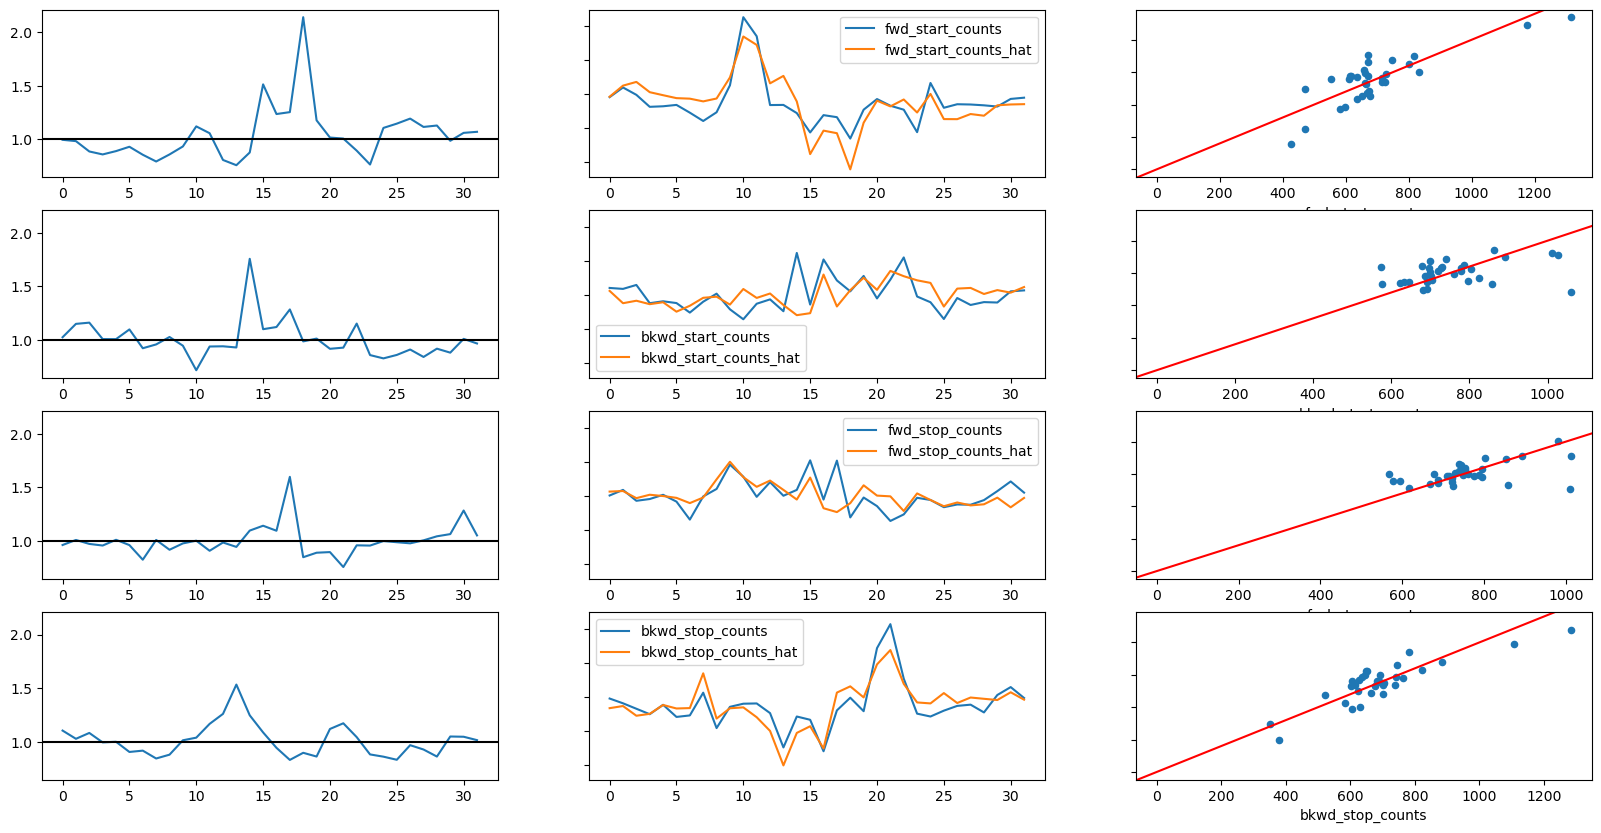

In [71]:
res.plot_summary()